In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

In [2]:
with open('gpt_f1_results_0.30_bal.json', 'r') as f:
    gpt_data = json.load(f)
    gpt_data = gpt_data['Total']

with open('bert_f1_results_0.30_bal.json', 'r') as f:
    bert_data = json.load(f)
    bert_data = bert_data['Total']

with open('results_balanced.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        key, value = line.split(": ")
        if key == "F1 Score":
            balanced_f1 = float(value)
        elif key == "Precision":
            balanced_precision = float(value)
        elif key == "Recall":
            balanced_recall = float(value)
    naive_llm_bal = {"F1": balanced_f1, "Precision": balanced_precision, "Recall": balanced_recall}

These json result files have the following fields:
    - F1
    - Precision
    - Recall
    - TP
    - FP
    - TN
    - FN

Here positive means malign prompts, negative means normal prompts

In [3]:
print(gpt_data)
print(bert_data)

{'TP': 1960, 'FP': 13, 'FN': 46, 'TN': 1993, 'Precision': 0.99341104916371, 'Recall': 0.9770687936191426, 'F1': 0.9851721538074893, 'Average Time': 0.30268895816232483, 'Average Time No Infer': 0.010802845298827942, 'Threshold': 0.3}
{'TP': 1899, 'FP': 110, 'FN': 107, 'TN': 1896, 'Precision': 0.9452463912394226, 'Recall': 0.9466600199401795, 'F1': 0.9459526774595267, 'Average Time': 0.01602075980643808, 'Average Time No Infer': 0.002327645288507342, 'Threshold': 0.3}


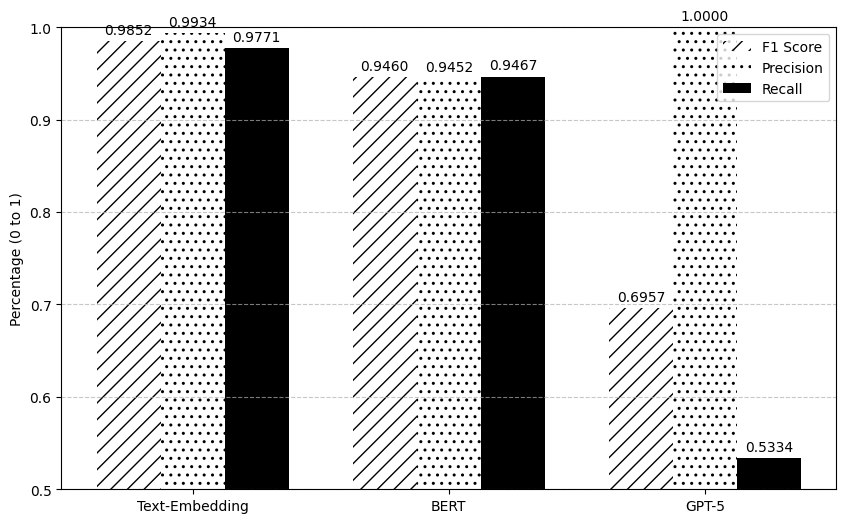

In [4]:
# Plotting F1 scores as a bar chart
labels = ['Text-Embedding', 'BERT', "GPT-5"]
f1_scores = [gpt_data['F1'], bert_data['F1'], naive_llm_bal['F1']]
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1 Score')
rects2 = ax.bar(x, [gpt_data['Precision'], bert_data['Precision'], naive_llm_bal['Precision']], width, label='Precision')
rects3 = ax.bar(x + width, [gpt_data['Recall'], bert_data['Recall'], naive_llm_bal['Recall']], width, label='Recall')

# Adding labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage (0 to 1)')

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0.5, 1)  # Set y-axis limits to [0, 1] for F1 scores
# Adding grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adding value labels on top of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

#Stripe one bar instead of solid color
for rect in rects1:
    rect.set_hatch('//')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects2:
    rect.set_hatch('..')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects3:
    rect.set_facecolor('black')

#legend
ax.legend()

# Show the plot
plt.show()

In [5]:
gpt_similarity_list = []
bert_similarity_list = []

with open("gpt_time_results_0.30_bal.json") as f:
    gpt_data = json.load(f)
    for key, value in gpt_data.items():
        if type(value) is dict:
            gpt_similarity_list.append((value['Similarity'], value['Label']))

with open("bert_time_results_0.30_bal.json") as f:
    bert_data = json.load(f)
    for key, value in bert_data.items():
        if type(value) is dict:
            bert_similarity_list.append((value['Similarity'], value['Label']))


In [6]:
def calculate_f1(data_list, threshold):
    tp = fp = fn = tn = 0
    for item in data_list:
        similarity = item[0]
        label = item[1]
        if similarity > threshold:
            if label == 0:
                tp += 1
            else:
                fp += 1
        else:
            if label == 1:
                tn += 1
            else:
                fn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {'Precision': precision, 'Recall': recall, 'F1': f1, 'Total': (tp + tn) / len(data_list)}

In [16]:
gpt_f1_results = {}
bert_f1_results = {}
value_range = np.arange(0.00, 1.01, 0.05)

for value in value_range:
    gpt_f1_results[value] = calculate_f1(gpt_similarity_list, value)
    bert_f1_results[value] = calculate_f1(bert_similarity_list, value)

print(gpt_f1_results[value_range[6]])

#write f1 results to json
with open('gpt_f1_range_0.30_bal.text', 'w') as f:
    for i in range(len(value_range)):
        value = value_range[i]
        f.write(f"{gpt_f1_results[value]['F1']}\n")
with open('bert_f1_range_0.30_bal.text', 'w') as f:
    for i in range(len(value_range)):
        value = value_range[i]
        f.write(f"{bert_f1_results[value]['F1']}\n")

{'Precision': 0.99341104916371, 'Recall': 0.9770687936191426, 'F1': 0.9851721538074893, 'Total': 0.9852941176470589}


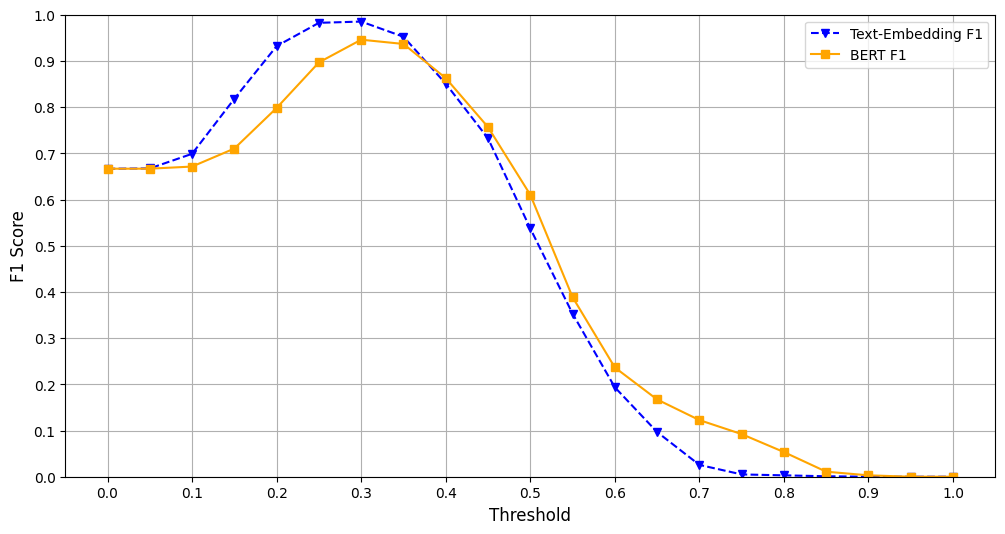

In [8]:
# Plot threshold vs f1 score line chart stored in gpt_f1_results and bert_f1_results
plt.figure(figsize=(12, 6))
plt.plot(value_range, [data['F1'] for data in gpt_f1_results.values()], label='Text-Embedding F1', marker='v')
plt.plot(value_range, [data['F1'] for data in bert_f1_results.values()], label='BERT F1', marker='s')
plt.xlabel('Threshold', fontsize=12)
#x labels at every 0.1
plt.xticks(np.arange(0, 1.1, 0.1))
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True)

#Change line style and color
lines = plt.gca().get_lines()
lines[0].set_linestyle('--')
lines[0].set_color('blue')
lines[1].set_linestyle('-')
lines[1].set_color('orange')

plt.legend()


In [9]:
gpt_f1_results_imba = {}
bert_f1_results_imba = {}
with open('bert_f1_results_0.30_imba.json', 'r') as f:
    bert_f1_results_imba = json.load(f)
    bert_f1_results_imba = bert_f1_results_imba['Total']

with open('gpt_time_results_0.30_imba.json', 'r') as f:
    gpt_data = json.load(f)
    gpt_similarity_list_imba = []
    for key, value in gpt_data.items():
        if type(value) is dict:
            gpt_similarity_list_imba.append((value['Similarity'], value['Label']))

with open("results_imbalanced.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        key, value = line.split(": ")
        if key == "F1 Score":
            imbalanced_f1 = float(value)
        elif key == "Precision":
            imbalanced_precision = float(value)
        elif key == "Recall":
            imbalanced_recall = float(value)
    naive_llm_imba = {"F1": imbalanced_f1, "Precision": imbalanced_precision, "Recall": imbalanced_recall}


gpt_f1_results_imba = calculate_f1(gpt_similarity_list_imba, 0.30)
print(gpt_f1_results_imba)
print(bert_f1_results_imba)

{'Precision': 0.9717402082300446, 'Recall': 0.9770687936191426, 'F1': 0.9743972160079541, 'Total': 0.992644958583262}
{'TP': 1899, 'FP': 689, 'FN': 107, 'TN': 11325, 'Precision': 0.7337712519319938, 'Recall': 0.9466600199401795, 'F1': 0.826730518067044, 'Average Time': 0.01662354496508284, 'Average Time No Infer': 0.0024192428282766303, 'Threshold': 0.3}


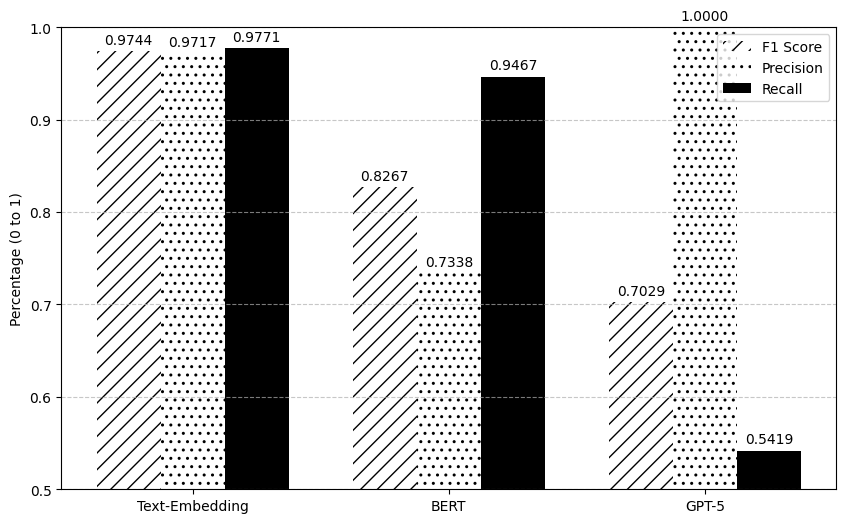

In [10]:
# Plotting F1 scores as a bar chart
labels = ['Text-Embedding', 'BERT', 'GPT-5']
f1_scores = [gpt_f1_results_imba['F1'], bert_f1_results_imba['F1'], naive_llm_imba['F1']]
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1 Score')
rects2 = ax.bar(x, [gpt_f1_results_imba['Precision'], bert_f1_results_imba['Precision'], naive_llm_imba['Precision']], width, label='Precision')
rects3 = ax.bar(x + width, [gpt_f1_results_imba['Recall'], bert_f1_results_imba['Recall'], naive_llm_imba['Recall']], width, label='Recall')

# Adding labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage (0 to 1)')

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0.5, 1)  # Set y-axis limits to [0, 1] for F1 scores
# Adding grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adding value labels on top of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

#Stripe one bar instead of solid color
for rect in rects1:
    rect.set_hatch('//')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects2:
    rect.set_hatch('..')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects3:
    rect.set_facecolor('black')

#legend
ax.legend()

# Show the plot
plt.show()

In [11]:
#embedding optimal threshold analysis
malicious_avg_gpt = 0
benign_avg_gpt = 0
malicious_avg_bert = 0
benign_avg_bert = 0
for value in gpt_similarity_list:
    if value[1] == 0:
        malicious_avg_gpt += value[0]
    else:
        benign_avg_gpt += value[0]

for value in bert_similarity_list:
    if value[1] == 0:
        malicious_avg_bert += value[0]
    else:
        benign_avg_bert += value[0]

malicious_avg_gpt /= len([v for v in gpt_similarity_list if v[1] == 0])
benign_avg_gpt /= len([v for v in gpt_similarity_list if v[1] == 1])
malicious_avg_bert /= len([v for v in bert_similarity_list if v[1] == 0])
benign_avg_bert /= len([v for v in bert_similarity_list if v[1] == 1])

optimal_threshold_gpt = (malicious_avg_gpt + benign_avg_gpt) / 2
optimal_threshold_bert = (malicious_avg_bert + benign_avg_bert) / 2

print("Optimal Threshold GPT:", optimal_threshold_gpt)
print("Optimal Threshold BERT:", optimal_threshold_bert)

Optimal Threshold GPT: 0.310986384081439
Optimal Threshold BERT: 0.34547376549864933


In [12]:
bert_similarity_list_imba = []
with open("bert_time_results_0.30_imba.json", "r") as f:
    bert_data = json.load(f)
    for key, value in bert_data.items():
        if type(value) is dict:
            bert_similarity_list_imba.append((value['Similarity'], value['Label']))

# Calculate F1 scores for the optimal thresholds
gpt_optimal_imba_f1 = calculate_f1(gpt_similarity_list_imba, optimal_threshold_gpt)
bert_optimal_imba_f1 = calculate_f1(bert_similarity_list_imba, optimal_threshold_bert)
gpt_optimal_bal_f1 = calculate_f1(gpt_similarity_list, optimal_threshold_gpt)
bert_optimal_bal_f1 = calculate_f1(bert_similarity_list, optimal_threshold_bert)
print("GPT Optimal Threshold F1 (Imbalanced):", gpt_optimal_imba_f1)
print("BERT Optimal Threshold F1 (Imbalanced):", bert_optimal_imba_f1)
print("GPT Optimal Threshold F1 (Balanced):", gpt_optimal_bal_f1)
print("BERT Optimal Threshold F1 (Balanced):", bert_optimal_bal_f1)

GPT Optimal Threshold F1 (Imbalanced): {'Precision': 0.9794589178356713, 'Recall': 0.9745762711864406, 'F1': 0.9770114942528735, 'Total': 0.9934304484433019}
BERT Optimal Threshold F1 (Imbalanced): {'Precision': 0.9016966067864272, 'Recall': 0.9007976071784646, 'F1': 0.9012468827930173, 'Total': 0.9717223650385605}
GPT Optimal Threshold F1 (Balanced): {'Precision': 0.9949109414758269, 'Recall': 0.9745762711864406, 'F1': 0.9846386300679929, 'Total': 0.9847956131605184}
BERT Optimal Threshold F1 (Balanced): {'Precision': 0.9799349240780911, 'Recall': 0.9007976071784646, 'F1': 0.9387012987012986, 'Total': 0.9411764705882353}


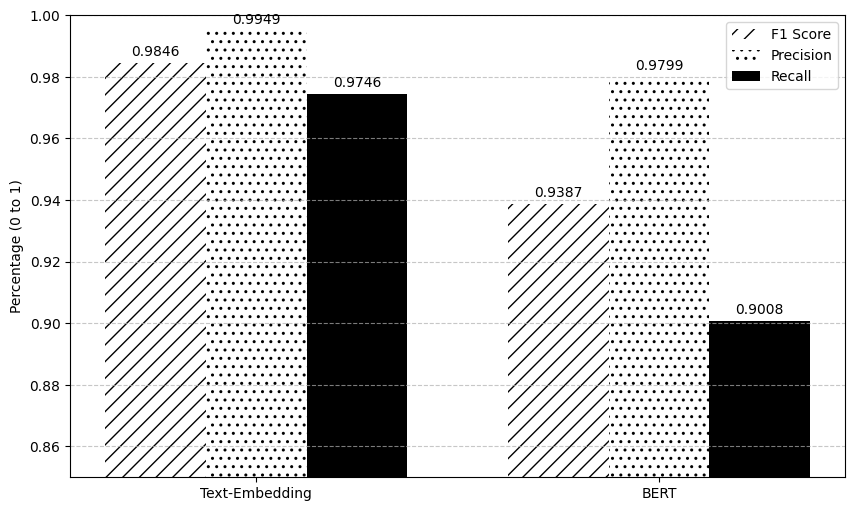

In [13]:
# Plotting F1 scores as a bar chart
labels = ['Text-Embedding', 'BERT']
f1_scores = [gpt_optimal_bal_f1['F1'], bert_optimal_bal_f1['F1']]
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1 Score')
rects2 = ax.bar(x, [gpt_optimal_bal_f1['Precision'], bert_optimal_bal_f1['Precision']], width, label='Precision')
rects3 = ax.bar(x + width, [gpt_optimal_bal_f1['Recall'], bert_optimal_bal_f1['Recall']], width, label='Recall')

# Adding labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage (0 to 1)')

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0.85, 1)  # Set y-axis limits to [0, 1] for F1 scores
# Adding grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adding value labels on top of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

#Stripe one bar instead of solid color
for rect in rects1:
    rect.set_hatch('//')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects2:
    rect.set_hatch('..')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects3:
    rect.set_facecolor('black')

#legend
ax.legend()

# Show the plot
plt.show()

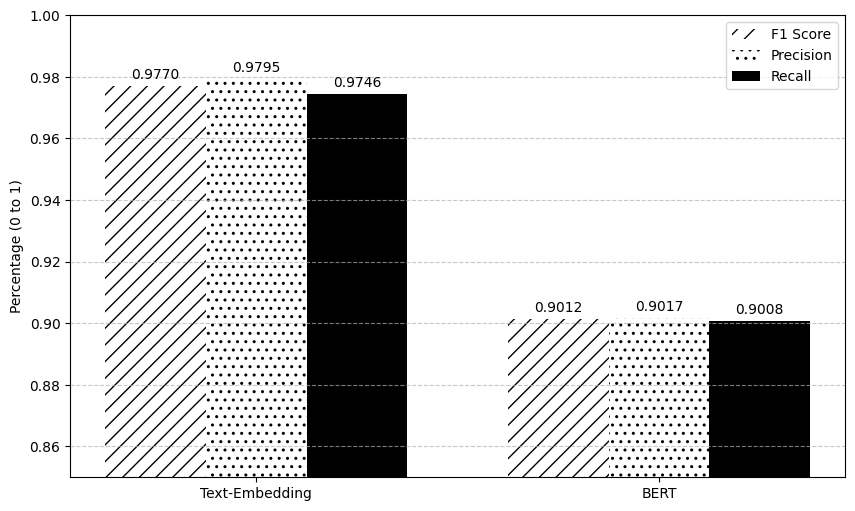

In [14]:
# Plotting F1 scores as a bar chart
labels = ['Text-Embedding', 'BERT']
f1_scores = [gpt_optimal_imba_f1['F1'], bert_optimal_imba_f1['F1']]
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1 Score')
rects2 = ax.bar(x, [gpt_optimal_imba_f1['Precision'], bert_optimal_imba_f1['Precision']], width, label='Precision')
rects3 = ax.bar(x + width, [gpt_optimal_imba_f1['Recall'], bert_optimal_imba_f1['Recall']], width, label='Recall')

# Adding labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Percentage (0 to 1)')

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0.85, 1)  # Set y-axis limits to [0, 1] for F1 scores
# Adding grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adding value labels on top of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

#Stripe one bar instead of solid color
for rect in rects1:
    rect.set_hatch('//')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects2:
    rect.set_hatch('..')
    #remove fill color
    rect.set_facecolor('none')

for rect in rects3:
    rect.set_facecolor('black')

#legend
ax.legend()

# Show the plot
plt.show()